In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Lock the base directory to wherever the Jupyter server was launched from
BASE_DIR = Path.cwd()
print(f"Working directory: {BASE_DIR}")  # Verify this prints your project root

# path
DATA_PATH = BASE_DIR / 'dataset' / 'raw' / 'uci_phishing.csv'
REPORTS_DIR = BASE_DIR / 'Reports'

# Verify file exists before loading
if not DATA_PATH.exists():
    raise FileNotFoundError(f"CSV not found at: {DATA_PATH}\nCheck your folder structure.")

os.makedirs(REPORTS_DIR, exist_ok=True)
sns.set_theme(style='whitegrid')

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Working directory: C:\phishing\phishing-detection-system
Shape: (11055, 31)

First 5 rows:


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [14]:
# Verify df exists in memory before trying to loop through its columns
if 'df' in locals() or 'df' in globals():
    print(f"Column names (Total: {len(df.columns)}):")
    print("-" * 40)
    for i, col in enumerate(df.columns, 1):
        print(f"  {i:2d}. {col}")
else:
    print("❌ Error: 'df' is not defined. Please run the first cell to load the dataset before running this check.")

Column names (Total: 31):
----------------------------------------
   1. having_IP_Address
   2. URL_Length
   3. Shortining_Service
   4. having_At_Symbol
   5. double_slash_redirecting
   6. Prefix_Suffix
   7. having_Sub_Domain
   8. SSLfinal_State
   9. Domain_registeration_length
  10. Favicon
  11. port
  12. HTTPS_token
  13. Request_URL
  14. URL_of_Anchor
  15. Links_in_tags
  16. SFH
  17. Submitting_to_email
  18. Abnormal_URL
  19. Redirect
  20. on_mouseover
  21. RightClick
  22. popUpWidnow
  23. Iframe
  24. age_of_domain
  25. DNSRecord
  26. web_traffic
  27. Page_Rank
  28. Google_Index
  29. Links_pointing_to_page
  30. Statistical_report
  31. Result


In [15]:
# Guard check to ensure df is loaded in memory
if 'df' in locals() or 'df' in globals():
    null_counts = df.isnull().sum()
    total_nulls = null_counts.sum()
    
    print("Missing values per column:")
    print("-" * 40)
    
    if total_nulls > 0:
        # Only show columns that actually have missing data to save space
        print(null_counts[null_counts > 0])
        print("-" * 40)
        print(f"Total missing cells: {total_nulls}")
    else:
        print("🎉 Clean dataset! No missing values (NaN) found across all 31 columns.")
else:
    print("❌ Error: 'df' is not defined. Please run your data loading cell first.")

Missing values per column:
----------------------------------------
🎉 Clean dataset! No missing values (NaN) found across all 31 columns.


Class distribution:
------------------------------
Result
 1    6157
-1    4898
Name: count, dtype: int64

Phishing: 6157 | Legitimate: 4898
------------------------------


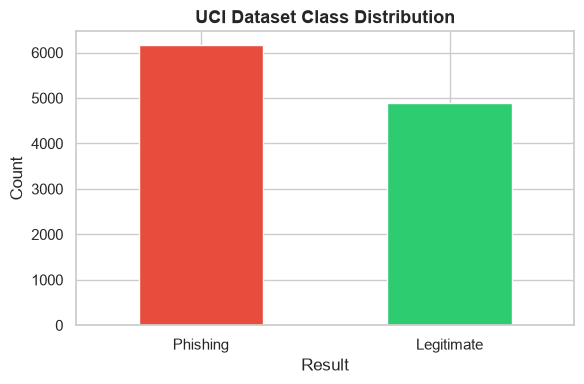

🎉 Chart successfully saved to: C:\phishing\phishing-detection-system\Reports\uci_class_distribution.png


In [16]:
# Guard check to ensure df is loaded in memory
if 'df' in locals() or 'df' in globals():
    # Class distribution
    # In UCI dataset the target is 'Result': 1=phishing, -1=legitimate
    target_col = 'Result'
    counts = df[target_col].value_counts()
    
    print("Class distribution:")
    print("-" * 30)
    print(counts)
    print(f"\nPhishing: {counts.get(1, 0)} | Legitimate: {counts.get(-1, 0)}")
    print("-" * 30)

    # Plot setup
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Map the exact color palette to your classification targets
    # (Note: index mapping ensures colors line up correctly with target keys)
    color_map = {1: '#e74c3c', -1: '#2ecc71'}
    bar_colors = [color_map.get(idx, '#7f8c8d') for idx in counts.index]
    
    counts.plot(kind='bar', ax=ax, color=bar_colors, edgecolor='white')
    
    ax.set_title('UCI Dataset Class Distribution', fontsize=13, fontweight='bold')
    
    # Map x-axis labels to match the value order (-1 or 1) automatically
    labels = ['Phishing' if idx == 1 else 'Legitimate' for idx in counts.index]
    ax.set_xticklabels(labels, rotation=0)
    ax.set_ylabel('Count')
    
    plt.tight_layout()
    
    # REAL FIX: Use your predefined REPORTS_DIR path object
    save_path = REPORTS_DIR / 'uci_class_distribution.png'
    plt.savefig(save_path, dpi=150)
    plt.show()
    
    print(f"🎉 Chart successfully saved to: {save_path}")
else:
    print("❌ Error: 'df' is not defined. Run cell 1 first.")

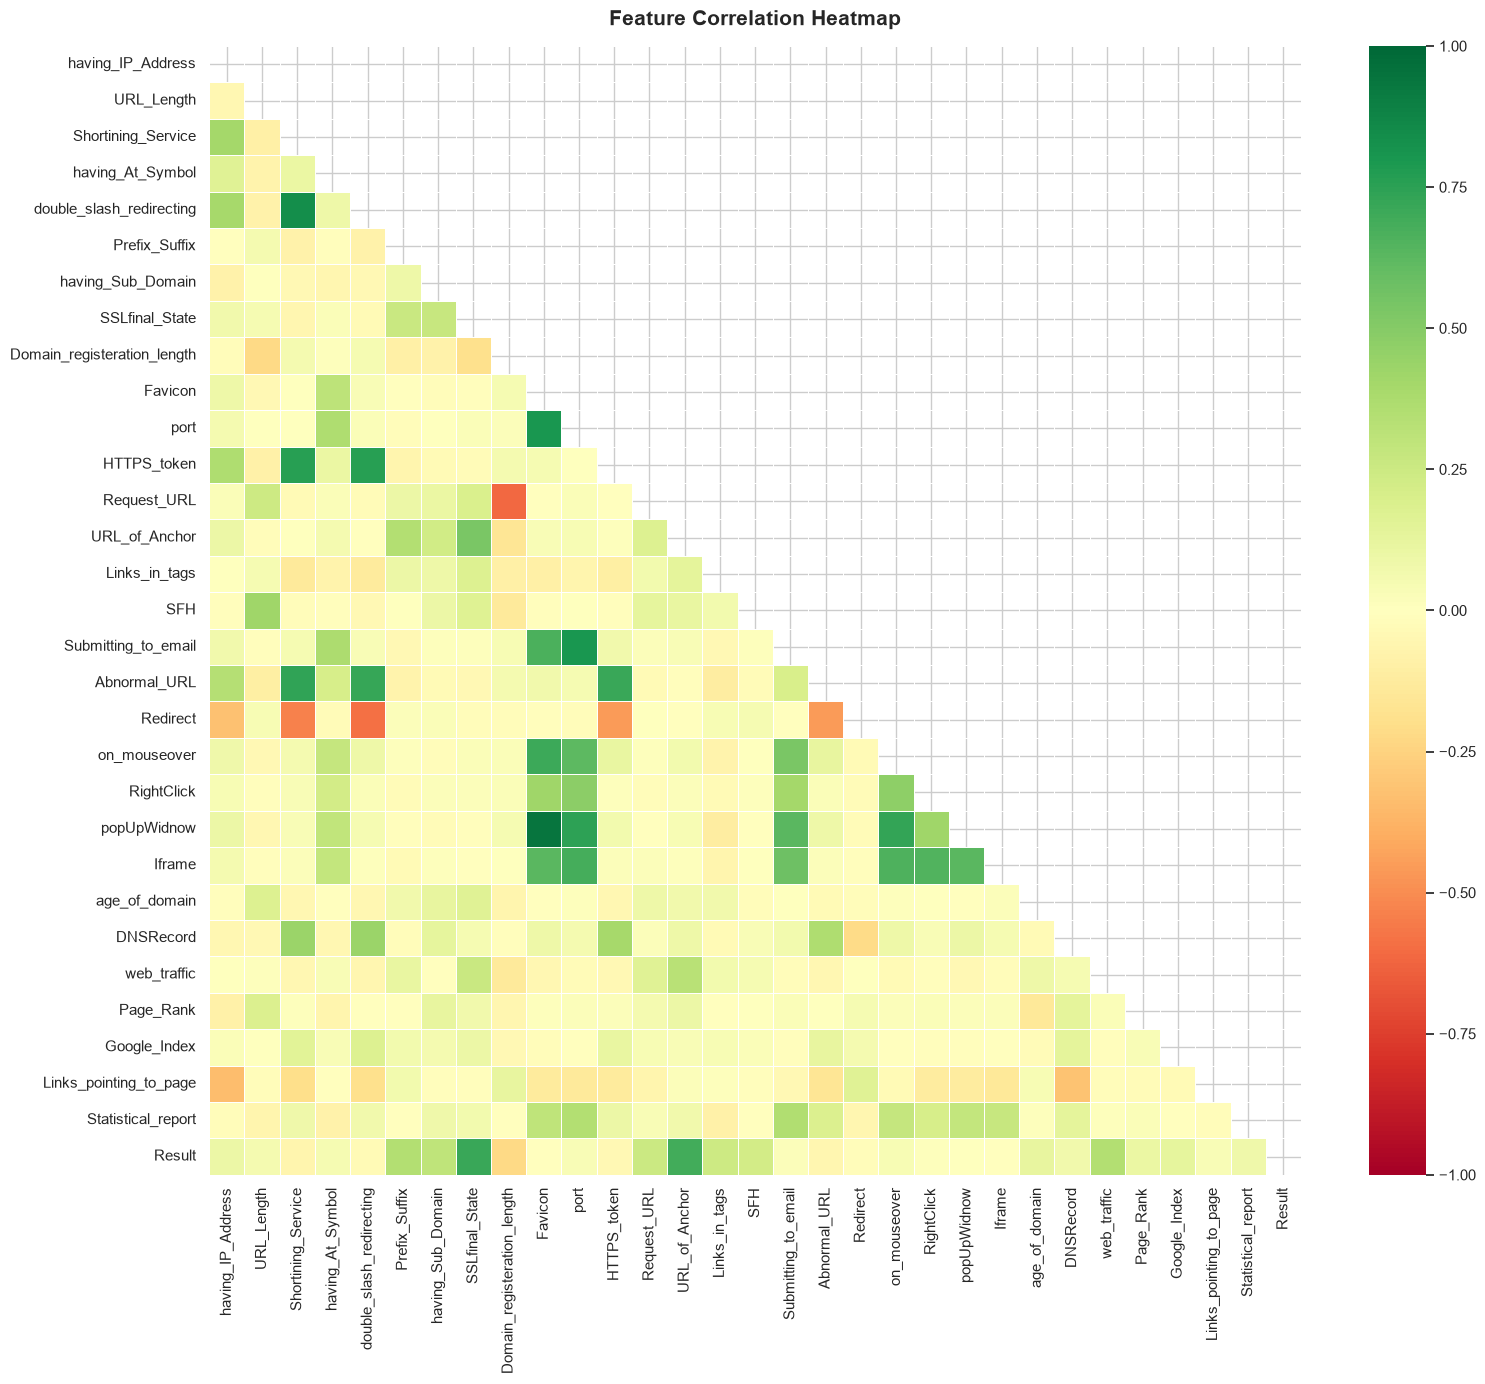

🎉 Heatmap successfully saved to: C:\phishing\phishing-detection-system\Reports\uci_correlation_heatmap.png


In [17]:
# Guard check to ensure df is loaded in memory
if 'df' in locals() or 'df' in globals():
    plt.figure(figsize=(16, 14))
    
    # Compute the linear correlation matrix
    corr = df.corr()
    
    # Create a mask for the upper triangle so we don't display duplicate information
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # Generate the heatmap with a diverging color scheme
    sns.heatmap(corr, mask=mask, annot=False, cmap='RdYlGn',
                linewidths=0.5, center=0, vmin=-1, vmax=1)
    
    plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
    plt.tight_layout()
    
    # REAL FIX: Use your predefined REPORTS_DIR path object
    save_path = REPORTS_DIR / 'uci_correlation_heatmap.png'
    plt.savefig(save_path, dpi=150)
    plt.show()
    
    print(f"🎉 Heatmap successfully saved to: {save_path}")
else:
    print("❌ Error: 'df' is not defined. Run cell 1 first.")

In [19]:
# Descriptive statistics
print("Descriptive statistics:")
df.describe().T

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
having_IP_Address,11055.0,0.313795,0.949534,-1.0,-1.0,1.0,1.0,1.0
URL_Length,11055.0,-0.633198,0.766095,-1.0,-1.0,-1.0,-1.0,1.0
Shortining_Service,11055.0,0.738761,0.673998,-1.0,1.0,1.0,1.0,1.0
having_At_Symbol,11055.0,0.700588,0.713598,-1.0,1.0,1.0,1.0,1.0
double_slash_redirecting,11055.0,0.741474,0.671011,-1.0,1.0,1.0,1.0,1.0
Prefix_Suffix,11055.0,-0.734962,0.678139,-1.0,-1.0,-1.0,-1.0,1.0
having_Sub_Domain,11055.0,0.063953,0.817518,-1.0,-1.0,0.0,1.0,1.0
SSLfinal_State,11055.0,0.250927,0.911892,-1.0,-1.0,1.0,1.0,1.0
Domain_registeration_length,11055.0,-0.336771,0.941629,-1.0,-1.0,-1.0,1.0,1.0
Favicon,11055.0,0.628584,0.777777,-1.0,1.0,1.0,1.0,1.0
